# Instalasi dan Inisialisasi Environment

In [4]:
!pip install pyspark -q

import warnings
warnings.filterwarnings('ignore')

print("✅ Dependencies siap")

✅ Dependencies siap


# Setup Mulai dari Fix CSV, Load Data, Parse, dan Feature Assembly

In [5]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════
# STEP 1: Fix CSV (sparse vector → dense vector)
# Hanya perlu dijalankan sekali, aman dijalankan berulang
# ════════════════════════════════════════════════
def to_dense_list(s):
    s = str(s).strip()
    if s.startswith('('):
        parts = ast.literal_eval(s)
        size, indices, values = int(parts[0]), list(parts[1]), list(parts[2])
        arr = np.zeros(size)
        for i, v in zip(indices, values):
            arr[i] = v
        return str(list(arr))
    return s

df_fix = pd.read_csv("final_dataset.csv")
df_fix['scaled_features'] = df_fix['scaled_features'].apply(to_dense_list)
df_fix.to_csv("final_dataset.csv", index=False)
print("✅ CSV sudah bersih (sparse vector dikonversi ke dense)")

# ════════════════════════════════════════════════
# STEP 2: Inisialisasi Spark
# ════════════════════════════════════════════════
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col as F_col

spark = SparkSession.builder \
    .appName("HR Attrition - ML Engineer") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print(f"✅ SparkSession aktif | Versi Spark: {spark.version}")

# ════════════════════════════════════════════════
# STEP 3: Load CSV ke Spark
# ════════════════════════════════════════════════
df_raw = spark.read.csv("final_dataset.csv", header=True, inferSchema=True)
print(f"✅ Data loaded: {df_raw.count()} baris")

# ════════════════════════════════════════════════
# STEP 4: Parse scaled_features string → DenseVector
# ════════════════════════════════════════════════
def parse_vector(s):
    try:
        parsed = ast.literal_eval(s)
        return Vectors.dense([float(x) for x in parsed])
    except:
        return None

parse_vector_udf = udf(parse_vector, VectorUDT())

df = df_raw.withColumn("scaled_features", parse_vector_udf(col("scaled_features"))) \
           .withColumn("Department_index", col("Department_index").cast("double")) \
           .withColumn("JobRole_index",    col("JobRole_index").cast("double")) \
           .withColumn("Gender_index",     col("Gender_index").cast("double")) \
           .withColumn("OverTime_index",   col("OverTime_index").cast("double")) \
           .withColumn("left_company",     col("left_company").cast("int"))

df = df.filter(col("scaled_features").isNotNull())
print(f"✅ DenseVector parsed: {df.count()} baris valid")

# ════════════════════════════════════════════════
# STEP 5: Feature Assembly
# ════════════════════════════════════════════════
df = df.withColumn("feat_arr", vector_to_array("scaled_features"))
feature_names = ["Age_scaled", "MonthlyIncome_scaled", "JobSatisfaction_scaled",
                 "PerformanceRating_scaled", "WorkLifeBalance_scaled", "YearsAtCompany_scaled"]
for i, name in enumerate(feature_names):
    df = df.withColumn(name, F_col("feat_arr")[i])

all_feature_cols = feature_names + ["Department_index", "JobRole_index", "Gender_index", "OverTime_index"]

assembler = VectorAssembler(inputCols=all_feature_cols, outputCol="features")
df_model = assembler.transform(df).select("features", "left_company")
df_model.cache()

print(f"✅ Feature vector siap | Jumlah fitur: {len(all_feature_cols)}")
print(f"   Fitur: {all_feature_cols}")
df_model.show(3, truncate=80)


✅ CSV sudah bersih (sparse vector dikonversi ke dense)
✅ SparkSession aktif | Versi Spark: 3.5.0
✅ Data loaded: 1470 baris
✅ DenseVector parsed: 1470 baris valid
✅ Feature vector siap | Jumlah fitur: 10
   Fitur: ['Age_scaled', 'MonthlyIncome_scaled', 'JobSatisfaction_scaled', 'PerformanceRating_scaled', 'WorkLifeBalance_scaled', 'YearsAtCompany_scaled', 'Department_index', 'JobRole_index', 'Gender_index', 'OverTime_index']
+--------------------------------------------------------------------------------+------------+
|                                                                        features|left_company|
+--------------------------------------------------------------------------------+------------+
|[0.5476190476190476,0.26245392311743027,1.0,0.0,0.0,0.15000000000000002,1.0,0...|           1|
|[0.738095238095238,0.21700895208004214,0.3333333333333333,1.0,0.6666666666666...|           0|
|[0.45238095238095233,0.0569246972090574,0.6666666666666666,0.0,0.666666666666...|          

# Exploratory Data Analysis (EDA)

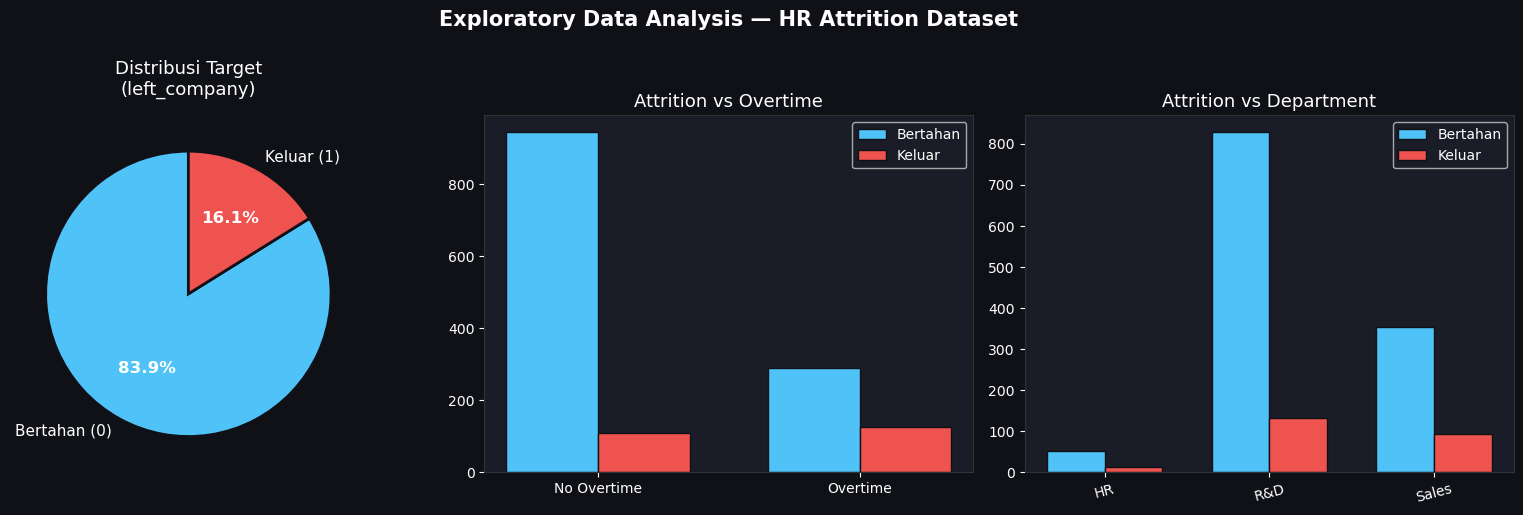


Class distribution:
left_company
0    1233
1     237
Name: count, dtype: int64
Imbalance ratio: 5.2:1


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import ast

# Gunakan df_raw (kolom masih string/int biasa, aman di-collect)
df_pd = df_raw.toPandas()
df_pd['scaled_features'] = df_pd['scaled_features'].apply(
    lambda s: ast.literal_eval(s) if isinstance(s, str) else s
)

# ── 1. Distribusi Target ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d27')

# Pie chart attrition
labels = ['Bertahan (0)', 'Keluar (1)']
sizes  = df_pd['left_company'].value_counts().sort_index().values
colors = ['#4fc3f7', '#ef5350']
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2),
    textprops=dict(color='white', fontsize=11)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[0].set_title('Distribusi Target\n(left_company)', color='white', fontsize=13, pad=15)

# Bar chart per OverTime
ot_labels = {0: 'No Overtime', 1: 'Overtime'}
df_pd['OverTime_label'] = df_pd['OverTime_index'].map(ot_labels)
ct = df_pd.groupby(['OverTime_label', 'left_company']).size().unstack(fill_value=0)
x = np.arange(len(ct.index))
w = 0.35
axes[1].bar(x - w/2, ct[0], w, label='Bertahan', color='#4fc3f7', edgecolor='#0f1117')
axes[1].bar(x + w/2, ct[1], w, label='Keluar',   color='#ef5350', edgecolor='#0f1117')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ct.index, color='white')
axes[1].set_title('Attrition vs Overtime', color='white', fontsize=13)
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#333')

# Bar chart per Department
dept_labels = {0: 'R&D', 1: 'Sales', 2: 'HR'}
df_pd['Dept_label'] = df_pd['Department_index'].map(dept_labels).fillna('Other')
ct2 = df_pd.groupby(['Dept_label', 'left_company']).size().unstack(fill_value=0)
x2 = np.arange(len(ct2.index))
axes[2].bar(x2 - w/2, ct2[0], w, label='Bertahan', color='#4fc3f7', edgecolor='#0f1117')
axes[2].bar(x2 + w/2, ct2[1], w, label='Keluar',   color='#ef5350', edgecolor='#0f1117')
axes[2].set_xticks(x2)
axes[2].set_xticklabels(ct2.index, color='white', rotation=15)
axes[2].set_title('Attrition vs Department', color='white', fontsize=13)
axes[2].tick_params(colors='white')
axes[2].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[2].spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('Exploratory Data Analysis — HR Attrition Dataset',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f"\nClass distribution:\n{df_pd['left_company'].value_counts()}")
print(f"Imbalance ratio: {df_pd['left_company'].value_counts()[0]/df_pd['left_company'].value_counts()[1]:.1f}:1")


# Train Test Split (80:20)

In [7]:
# Split 80:20 sesuai PRD
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

print(f"✅ Dataset berhasil di-split")
print(f"   Training set : {train_data.count()} baris")
print(f"   Testing set  : {test_data.count()} baris")

print("\nDistribusi train:")
train_data.groupBy("left_company").count().show()
print("Distribusi test:")
test_data.groupBy("left_company").count().show()


✅ Dataset berhasil di-split
   Training set : 1216 baris
   Testing set  : 254 baris

Distribusi train:
+------------+-----+
|left_company|count|
+------------+-----+
|           1|  194|
|           0| 1022|
+------------+-----+

Distribusi test:
+------------+-----+
|left_company|count|
+------------+-----+
|           1|   43|
|           0|  211|
+------------+-----+



# Model 1 (Random Forest Classifier)

In [8]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="left_company",
    numTrees=100,
    maxDepth=5,
    seed=42
)

print("⏳ Melatih Random Forest... (100 trees)")
rf_model = rf.fit(train_data)
print("✅ Training selesai!")

rf_pred = rf_model.transform(test_data)
rf_pred.select("left_company", "prediction", "probability").show(10)


⏳ Melatih Random Forest... (100 trees)
✅ Training selesai!
+------------+----------+--------------------+
|left_company|prediction|         probability|
+------------+----------+--------------------+
|           0|       0.0|[0.75051175116703...|
|           0|       0.0|[0.75296333768222...|
|           0|       0.0|[0.86276018119804...|
|           1|       0.0|[0.83566604657543...|
|           0|       0.0|[0.84555269714409...|
|           0|       0.0|[0.91435463647188...|
|           1|       0.0|[0.85004787958477...|
|           0|       0.0|[0.87060027514409...|
|           1|       0.0|[0.89032253048938...|
|           0|       0.0|[0.89593573857535...|
+------------+----------+--------------------+
only showing top 10 rows



# Evaluasi Random Forest

In [9]:
bin_eval = BinaryClassificationEvaluator(labelCol="left_company", rawPredictionCol="rawPrediction")
mc_eval  = MulticlassClassificationEvaluator(labelCol="left_company", predictionCol="prediction")

rf_auc       = bin_eval.evaluate(rf_pred)
rf_precision = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "weightedPrecision"})
rf_recall    = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "weightedRecall"})
rf_f1        = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "f1"})
rf_acc       = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "accuracy"})

print("=" * 45)
print("  📊 EVALUASI RANDOM FOREST CLASSIFIER")
print("=" * 45)
print(f"  AUC-ROC   : {rf_auc:.4f}")
print(f"  Accuracy  : {rf_acc:.4f}")
print(f"  Precision : {rf_precision:.4f}")
print(f"  Recall    : {rf_recall:.4f}")
print(f"  F1-Score  : {rf_f1:.4f}")
print("=" * 45)

rf_metrics = {
    "Model": "Random Forest",
    "AUC-ROC": rf_auc, "Accuracy": rf_acc,
    "Precision": rf_precision, "Recall": rf_recall, "F1-Score": rf_f1
}

  📊 EVALUASI RANDOM FOREST CLASSIFIER
  AUC-ROC   : 0.8146
  Accuracy  : 0.8346
  Precision : 0.7963
  Recall    : 0.8346
  F1-Score  : 0.7816


# Feature Importance

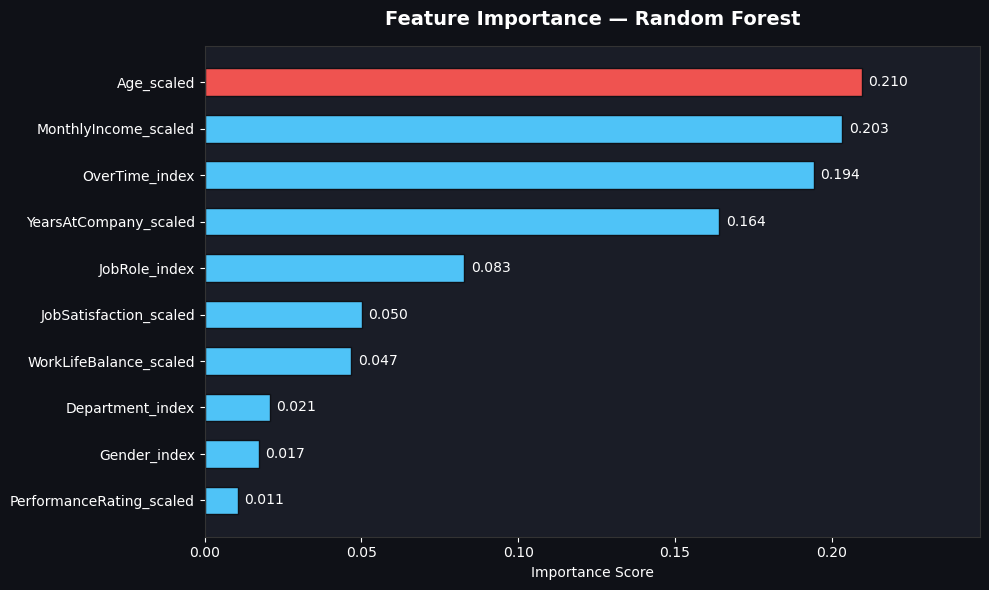

In [10]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf_model.featureImportances.toArray()
fi_df = sorted(zip(all_feature_cols, importances), key=lambda x: x[1], reverse=True)
names, vals = zip(*fi_df)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

colors_bar = ['#ef5350' if v == max(vals) else '#4fc3f7' for v in vals]
bars = ax.barh(names[::-1], vals[::-1], color=colors_bar[::-1], edgecolor='#0f1117', height=0.6)
for bar, val in zip(bars, vals[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=10)

ax.set_title('Feature Importance — Random Forest', color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.set_xlim(0, max(vals) * 1.18)

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


# Model 2 Logistic Regression Beserta Evaluasi

In [11]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="left_company",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

print("⏳ Melatih Logistic Regression...")
lr_model = lr.fit(train_data)
print("✅ Training selesai!")

lr_pred = lr_model.transform(test_data)

lr_auc       = bin_eval.evaluate(lr_pred)
lr_precision = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "weightedPrecision"})
lr_recall    = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "weightedRecall"})
lr_f1        = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "f1"})
lr_acc       = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "accuracy"})

print("=" * 45)
print("  📊 EVALUASI LOGISTIC REGRESSION")
print("=" * 45)
print(f"  AUC-ROC   : {lr_auc:.4f}")
print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {lr_precision:.4f}")
print(f"  Recall    : {lr_recall:.4f}")
print(f"  F1-Score  : {lr_f1:.4f}")
print("=" * 45)

lr_metrics = {
    "Model": "Logistic Regression",
    "AUC-ROC": lr_auc, "Accuracy": lr_acc,
    "Precision": lr_precision, "Recall": lr_recall, "F1-Score": lr_f1
}


⏳ Melatih Logistic Regression...
✅ Training selesai!
  📊 EVALUASI LOGISTIC REGRESSION
  AUC-ROC   : 0.7640
  Accuracy  : 0.8465
  Precision : 0.8704
  Recall    : 0.8465
  F1-Score  : 0.7892


# Confusion Matrix (Kedua Model)

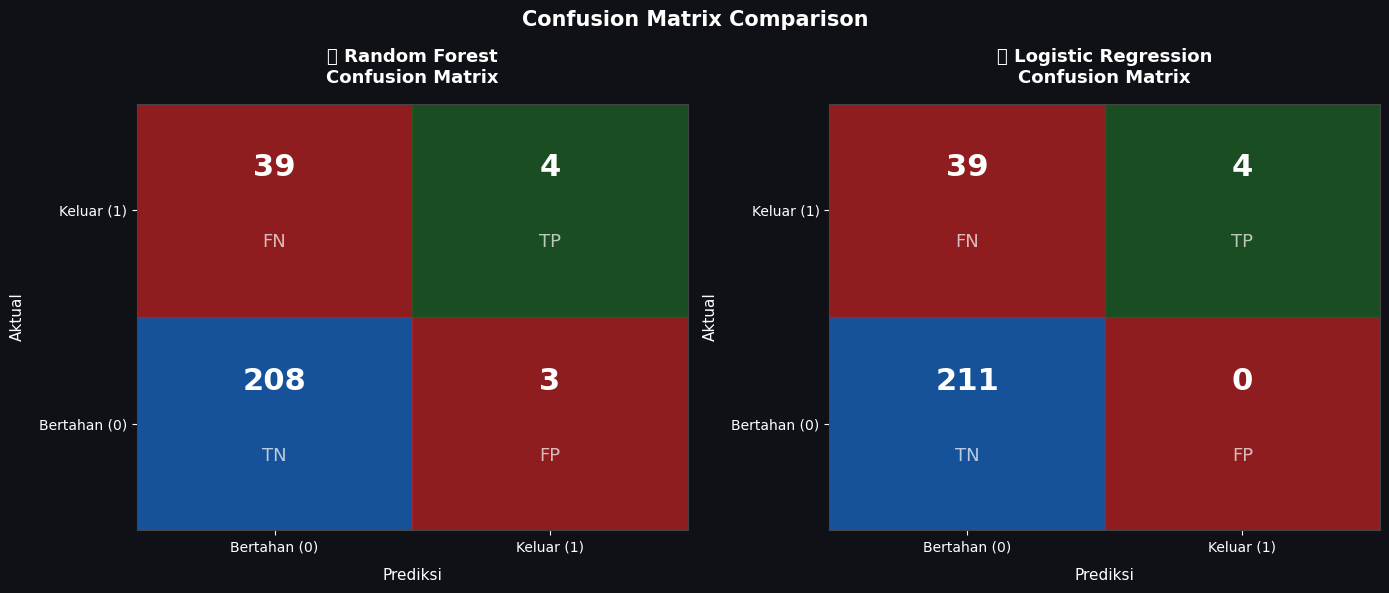

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def compute_confusion_matrix(predictions_df, label_col="left_company", pred_col="prediction"):
    pdf = predictions_df.select(label_col, pred_col).toPandas()
    tp = len(pdf[(pdf[label_col]==1) & (pdf[pred_col]==1)])
    tn = len(pdf[(pdf[label_col]==0) & (pdf[pred_col]==0)])
    fp = len(pdf[(pdf[label_col]==0) & (pdf[pred_col]==1)])
    fn = len(pdf[(pdf[label_col]==1) & (pdf[pred_col]==0)])
    return np.array([[tn, fp], [fn, tp]])

rf_cm = compute_confusion_matrix(rf_pred)
lr_cm = compute_confusion_matrix(lr_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

def plot_cm(ax, cm, title):
    ax.set_facecolor('#1a1d27')

    # Warna per sel: hijau=benar (TN,TP), merah=salah (FP,FN)
    cell_colors = np.array([
        ['#1565c0', '#b71c1c'],  # TN biru, FP merah
        ['#b71c1c', '#1b5e20'],  # FN merah, TP hijau
    ], dtype=object)

    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                color=cell_colors[i][j], alpha=0.75, zorder=0
            ))

    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i - 0.15, cell_labels[i][j],
                    ha='center', va='center', fontsize=13,
                    color='white', alpha=0.7, zorder=2)
            ax.text(j, i + 0.2, str(cm[i, j]),
                    ha='center', va='center', fontsize=22,
                    fontweight='bold', color='white', zorder=2)

    tick_labels = ['Bertahan (0)', 'Keluar (1)']
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(tick_labels, color='white', fontsize=10)
    ax.set_yticklabels(tick_labels, color='white', fontsize=10)
    ax.set_xlabel('Prediksi', color='white', fontsize=11, labelpad=10)
    ax.set_ylabel('Aktual', color='white', fontsize=11, labelpad=10)
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plot_cm(axes[0], rf_cm, '🌲 Random Forest\nConfusion Matrix')
plot_cm(axes[1], lr_cm, '📈 Logistic Regression\nConfusion Matrix')

plt.suptitle('Confusion Matrix Comparison', color='white', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Perbadingan Kedua Model

Metrik                Random Forest     Logistic Reg
AUC-ROC            0.8146 (*)   0.7640    
Accuracy           0.8346       0.8465 (*)
Precision          0.7963       0.8704 (*)
Recall             0.8346       0.8465 (*)
F1-Score           0.7816       0.7892 (*)
  (*) = nilai lebih tinggi


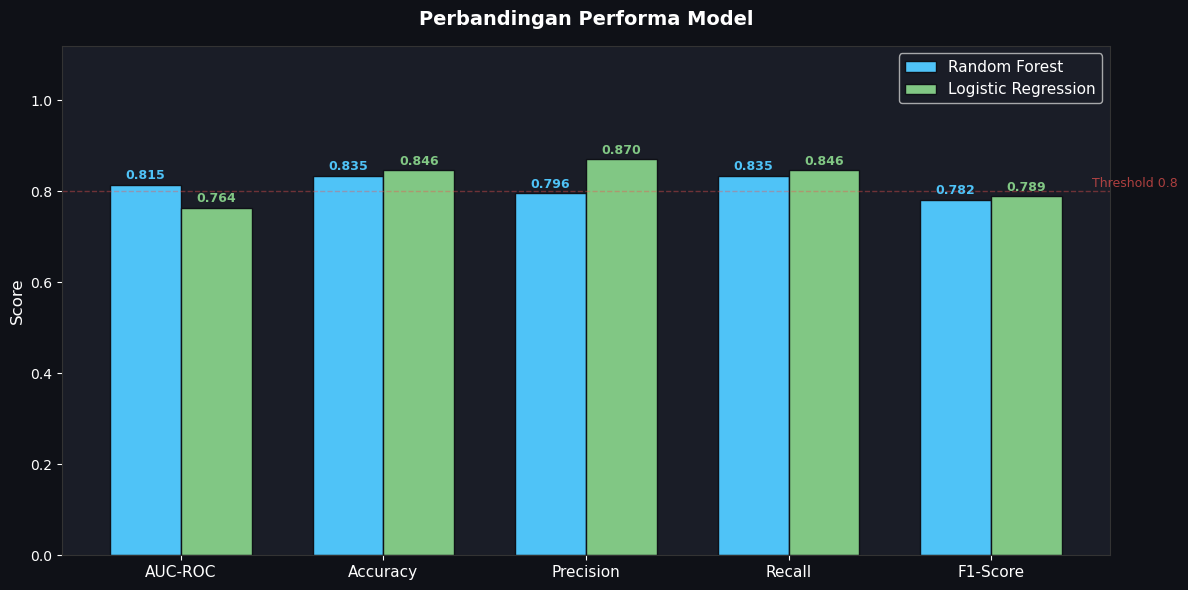

In [13]:

import matplotlib.pyplot as plt
import numpy as np

metric_names = ["AUC-ROC", "Accuracy", "Precision", "Recall", "F1-Score"]

print("=" * 58)
print(f"{'Metrik':<18} {'Random Forest':>16} {'Logistic Reg':>16}")
print("=" * 58)
for m in metric_names:
    rf_v = rf_metrics[m]
    lr_v = lr_metrics[m]
    rf_mark = " (*)" if rf_v >= lr_v else "    "
    lr_mark = " (*)" if lr_v > rf_v  else "    "
    print(f"{m:<18} {rf_v:.4f}{rf_mark:>4}   {lr_v:.4f}{lr_mark:>4}")
print("=" * 58)
print("  (*) = nilai lebih tinggi")

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

b1 = ax.bar(x - width/2, [rf_metrics[m] for m in metric_names], width,
            label='Random Forest', color='#4fc3f7', edgecolor='#0f1117')
b2 = ax.bar(x + width/2, [lr_metrics[m] for m in metric_names], width,
            label='Logistic Regression', color='#81c784', edgecolor='#0f1117')

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', color='#4fc3f7', fontsize=9, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', color='#81c784', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, color='white', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', color='white', fontsize=12)
ax.set_title('Perbandingan Performa Model', color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=11)
ax.axhline(y=0.8, color='#ef5350', linestyle='--', alpha=0.4, linewidth=1)
ax.text(len(metric_names)-0.5, 0.81, 'Threshold 0.8', color='#ef5350', fontsize=9, alpha=0.7)
for spine in ax.spines.values():
    spine.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Analisis K-Means Clustering (Segmentasi Karyawan)

⏳ Menghitung Elbow Method (k=2 hingga 7)...
  k=2 → WSSSE: 3707.34
  k=3 → WSSSE: 2506.67
  k=4 → WSSSE: 1995.78
  k=5 → WSSSE: 1867.51
  k=6 → WSSSE: 1679.52
  k=7 → WSSSE: 1589.46


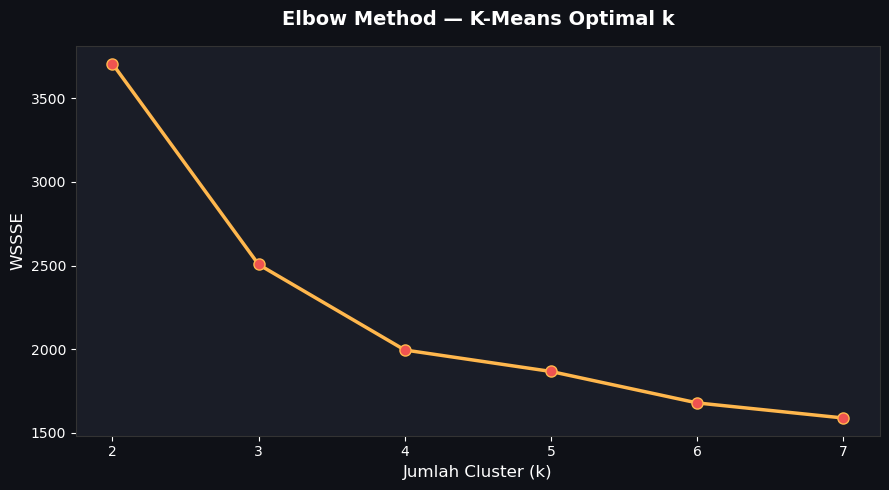


💡 Pilih k di titik 'siku' — biasanya k=3 atau k=4


In [14]:
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

print("⏳ Menghitung Elbow Method (k=2 hingga 7)...")
costs = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(featuresCol="features", k=k, seed=42, maxIter=20)
    km_model = km.fit(df_model)
    costs.append(km_model.summary.trainingCost)
    print(f"  k={k} → WSSSE: {km_model.summary.trainingCost:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
ax.plot(list(k_range), costs, 'o-', color='#ffb74d', linewidth=2.5, markersize=8, markerfacecolor='#ef5350')
ax.set_xlabel('Jumlah Cluster (k)', color='white', fontsize=12)
ax.set_ylabel('WSSSE', color='white', fontsize=12)
ax.set_title('Elbow Method — K-Means Optimal k', color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.set_xticks(list(k_range))
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("\n💡 Pilih k di titik 'siku' — biasanya k=3 atau k=4")


In [15]:
# Sesuaikan K_OPTIMAL berdasarkan hasil elbow di atas
K_OPTIMAL = 3

km_final     = KMeans(featuresCol="features", k=K_OPTIMAL, seed=42, maxIter=50)
km_model     = km_final.fit(df_model)
df_clustered = km_model.transform(df_model)

print(f"✅ K-Means selesai dengan k={K_OPTIMAL}")
print("\nDistribusi attrition per cluster:")
df_clustered.groupBy("prediction", "left_company").count() \
    .orderBy("prediction", "left_company").show()

cluster_stats = df_clustered.groupBy("prediction").agg(
    {"left_company": "sum", "*": "count"}
).toDF("cluster", "attrition_count", "total")
cluster_stats = cluster_stats.withColumn(
    "attrition_rate",
    (cluster_stats.attrition_count / cluster_stats.total * 100)
)
print("\nAttrition rate per cluster:")
cluster_stats.orderBy("cluster").show()

✅ K-Means selesai dengan k=3

Distribusi attrition per cluster:
+----------+------------+-----+
|prediction|left_company|count|
+----------+------------+-----+
|         0|           0|  454|
|         0|           1|   81|
|         1|           0|  514|
|         1|           1|  104|
|         2|           0|  265|
|         2|           1|   52|
+----------+------------+-----+


Attrition rate per cluster:
+-------+---------------+-----+-----------------+
|cluster|attrition_count|total|   attrition_rate|
+-------+---------------+-----+-----------------+
|      0|            535|   81|660.4938271604939|
|      1|            618|  104|594.2307692307693|
|      2|            317|   52|609.6153846153845|
+-------+---------------+-----+-----------------+



# Visualisasi Cluster

Cek data cluster:
   prediction  attrition  total  stay  rate
0           0         81    535   454  15.1
1           1        104    618   514  16.8
2           2         52    317   265  16.4


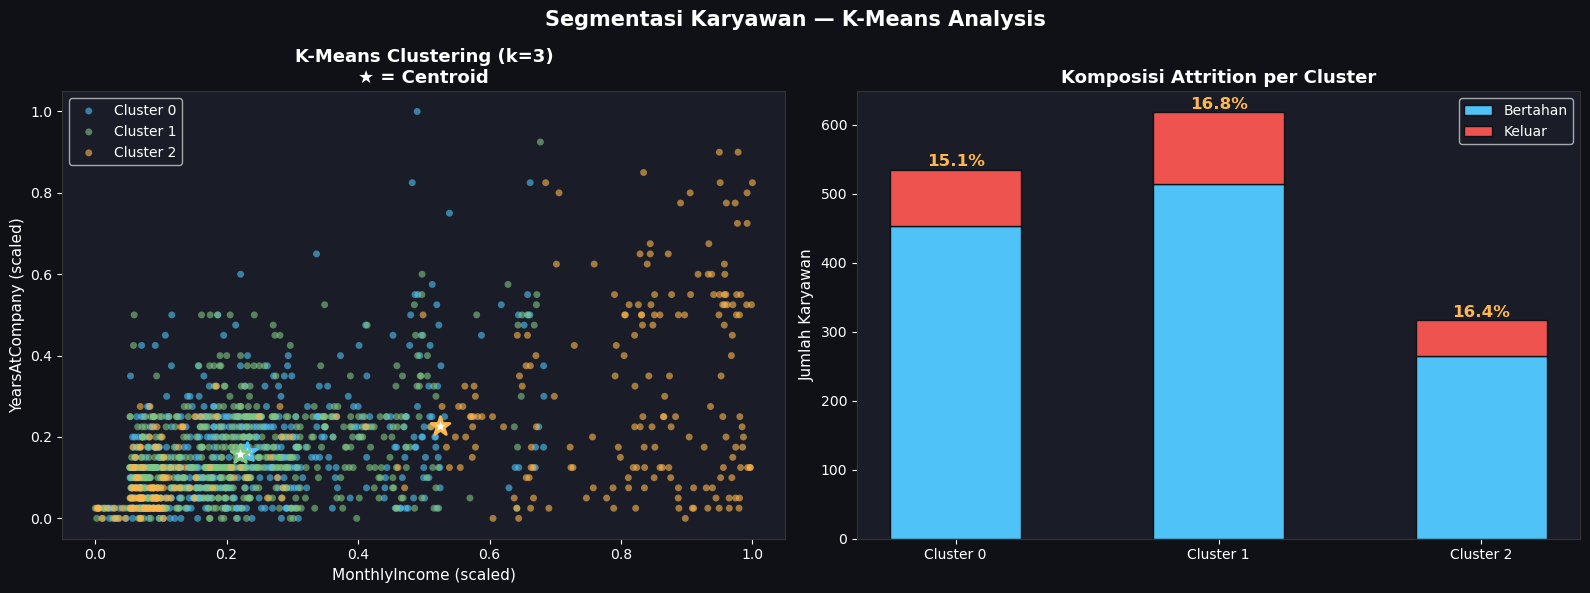

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col as F_col, sum as F_sum, count as F_count

df_plot = df_clustered.select(
    vector_to_array("features").alias("f"),
    "prediction", "left_company"
).toPandas()

df_plot["MonthlyIncome_s"]  = df_plot["f"].apply(lambda x: x[1])
df_plot["YearsAtCompany_s"] = df_plot["f"].apply(lambda x: x[5])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d27')

cluster_colors = ['#4fc3f7', '#81c784', '#ffb74d', '#ce93d8', '#ef5350']

for c in range(K_OPTIMAL):
    mask = df_plot["prediction"] == c
    axes[0].scatter(df_plot.loc[mask, "MonthlyIncome_s"],
                    df_plot.loc[mask, "YearsAtCompany_s"],
                    c=cluster_colors[c], label=f"Cluster {c}",
                    alpha=0.6, s=25, edgecolors='none')

centers = km_model.clusterCenters()
for i, center in enumerate(centers):
    axes[0].scatter(center[1], center[5], c='white', s=200, marker='*',
                    edgecolors=cluster_colors[i], linewidths=2, zorder=10)

axes[0].set_xlabel('MonthlyIncome (scaled)', color='white', fontsize=11)
axes[0].set_ylabel('YearsAtCompany (scaled)', color='white', fontsize=11)
axes[0].set_title(f'K-Means Clustering (k={K_OPTIMAL})\n★ = Centroid', color='white', fontsize=13, fontweight='bold')
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[0].spines.values():
    spine.set_edgecolor('#333')

# ── Fix aggregasi: eksplisit pakai nama kolom ──
cluster_pd = df_clustered.groupBy("prediction").agg(
    F_sum("left_company").alias("attrition"),
    F_count("*").alias("total")
).toPandas()

cluster_pd = cluster_pd.sort_values("prediction").reset_index(drop=True)
cluster_pd["stay"] = cluster_pd["total"] - cluster_pd["attrition"]
cluster_pd["rate"] = (cluster_pd["attrition"] / cluster_pd["total"] * 100).round(1)

print("Cek data cluster:")
print(cluster_pd)

x = np.arange(K_OPTIMAL)
w = 0.5
axes[1].bar(x, cluster_pd["stay"],      w, label='Bertahan', color='#4fc3f7', edgecolor='#0f1117')
axes[1].bar(x, cluster_pd["attrition"], w, label='Keluar',   color='#ef5350', edgecolor='#0f1117',
            bottom=cluster_pd["stay"])

for i, (_, row) in enumerate(cluster_pd.iterrows()):
    axes[1].text(i, row["total"] + 5, f'{row["rate"]:.1f}%',
                 ha='center', color='#ffb74d', fontsize=12, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {c}' for c in cluster_pd["prediction"]], color='white')
axes[1].set_title('Komposisi Attrition per Cluster', color='white', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Karyawan', color='white', fontsize=11)
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('Segmentasi Karyawan — K-Means Analysis', color='white', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clustering.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Interpretasi Hasil

In [14]:
print("=" * 60)
print("       📋 RINGKASAN HASIL ANALITIK — HR ATTRITION")
print("=" * 60)

print("\n🎯 PERFORMA MODEL:")
print(f"  ┌─ Random Forest   → AUC-ROC: {rf_auc:.4f} | F1: {rf_f1:.4f}")
print(f"  └─ Log. Regression → AUC-ROC: {lr_auc:.4f} | F1: {lr_f1:.4f}")
best = "Random Forest" if rf_auc >= lr_auc else "Logistic Regression"
print(f"\n  ✅ Model terbaik: {best}")

print("\n📊 DISTRIBUSI DATASET:")
print(f"  Total karyawan  : 1.470")
print(f"  Bertahan (No)   : 1.233 (83.9%)")
print(f"  Keluar (Yes)    : 237   (16.1%)")
print(f"  Imbalance ratio : ~5.2:1")

print("\n💡 REKOMENDASI HR BERDASARKAN FEATURE IMPORTANCE:")
feature_importance_ranked = sorted(
    zip(all_feature_cols, rf_model.featureImportances.toArray()),
    key=lambda x: x[1], reverse=True
)
print("  Top 3 faktor penyebab attrition:")
for i, (feat, score) in enumerate(feature_importance_ranked[:3], 1):
    feat_readable = feat.replace("_scaled","").replace("_index","")
    print(f"  {i}. {feat_readable:<25} (importance: {score:.4f})")

print("\n🔍 SEGMENTASI K-MEANS:")
print(f"  Cluster dengan attrition rate tertinggi = karyawan BERISIKO TINGGI")
print(f"  → Prioritaskan program retensi untuk cluster tersebut")

print("\n📌 TINDAKAN PREVENTIF YANG DIREKOMENDASIKAN:")
print("  1. Review kebijakan Overtime untuk karyawan berisiko tinggi")
print("  2. Program peningkatan kepuasan kerja (JobSatisfaction)")
print("  3. Competitive salary review untuk segmen MonthlyIncome rendah")
print("  4. Career development plan untuk karyawan dengan YearsAtCompany < 3")
print("=" * 60)


       📋 RINGKASAN HASIL ANALITIK — HR ATTRITION

🎯 PERFORMA MODEL:
  ┌─ Random Forest   → AUC-ROC: 0.8146 | F1: 0.7816
  └─ Log. Regression → AUC-ROC: 0.7640 | F1: 0.7892

  ✅ Model terbaik: Random Forest

📊 DISTRIBUSI DATASET:
  Total karyawan  : 1.470
  Bertahan (No)   : 1.233 (83.9%)
  Keluar (Yes)    : 237   (16.1%)
  Imbalance ratio : ~5.2:1

💡 REKOMENDASI HR BERDASARKAN FEATURE IMPORTANCE:
  Top 3 faktor penyebab attrition:
  1. Age                       (importance: 0.2096)
  2. MonthlyIncome             (importance: 0.2034)
  3. OverTime                  (importance: 0.1944)

🔍 SEGMENTASI K-MEANS:
  Cluster dengan attrition rate tertinggi = karyawan BERISIKO TINGGI
  → Prioritaskan program retensi untuk cluster tersebut

📌 TINDAKAN PREVENTIF YANG DIREKOMENDASIKAN:
  1. Review kebijakan Overtime untuk karyawan berisiko tinggi
  2. Program peningkatan kepuasan kerja (JobSatisfaction)
  3. Competitive salary review untuk segmen MonthlyIncome rendah
  4. Career development plan un

# Untuk Simpan Hasil

In [15]:
import pandas as pd

metrics_df = pd.DataFrame([rf_metrics, lr_metrics])
metrics_df.to_csv("model_metrics.csv", index=False)
print("✅ model_metrics.csv disimpan")

rf_pred.select("left_company", "prediction", "probability") \
    .toPandas().to_csv("rf_predictions.csv", index=False)
print("✅ rf_predictions.csv disimpan")

lr_pred.select("left_company", "prediction", "probability") \
    .toPandas().to_csv("lr_predictions.csv", index=False)
print("✅ lr_predictions.csv disimpan")

df_clustered.select("left_company", "prediction") \
    .toPandas().to_csv("clustering_results.csv", index=False)
print("✅ clustering_results.csv disimpan")

print("\n📁 File output:")
print("   ├─ model_metrics.csv")
print("   ├─ rf_predictions.csv")
print("   ├─ lr_predictions.csv")
print("   ├─ clustering_results.csv")
print("   ├─ eda_distribution.png")
print("   ├─ rf_feature_importance.png")
print("   ├─ confusion_matrix.png")
print("   ├─ model_comparison.png")
print("   ├─ kmeans_elbow.png")
print("   └─ kmeans_clustering.png")


✅ model_metrics.csv disimpan
✅ rf_predictions.csv disimpan
✅ lr_predictions.csv disimpan
✅ clustering_results.csv disimpan

📁 File output:
   ├─ model_metrics.csv
   ├─ rf_predictions.csv
   ├─ lr_predictions.csv
   ├─ clustering_results.csv
   ├─ eda_distribution.png
   ├─ rf_feature_importance.png
   ├─ confusion_matrix.png
   ├─ model_comparison.png
   ├─ kmeans_elbow.png
   └─ kmeans_clustering.png
